In [1]:
# Importing the libraries needed for this project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Uploading the Wine Quality dataset

from google.colab import files
import zipfile
import os

uploaded = files.upload()

# If a ZIP file is uploaded, extract it
for file_name in uploaded.keys():
    if file_name.endswith(".zip"):
        with zipfile.ZipFile(file_name, "r") as zip_ref:
            zip_ref.extractall("wine_data")
        print("ZIP file extracted successfully!")

# Find the CSV file
csv_file = None

for root, dirs, files_list in os.walk("."):
    for file in files_list:
        if file.endswith(".csv") and "wine" in file.lower():
            csv_file = os.path.join(root, file)
            break
    if csv_file:
        break

# Load the dataset
df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Saving archive.zip to archive.zip
ZIP file extracted successfully!
Dataset loaded successfully!
Shape: (1143, 13)


In [3]:
# Checking the columns and first few rows

print("Columns in the dataset:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Columns in the dataset:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
# Checking the dataset structure and missing values

print("Dataset information:")
df.info()

print("\nMissing values in each column:")
print(df.isnull().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

Missing values in each column:
fixed acidity         

Wine quality distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


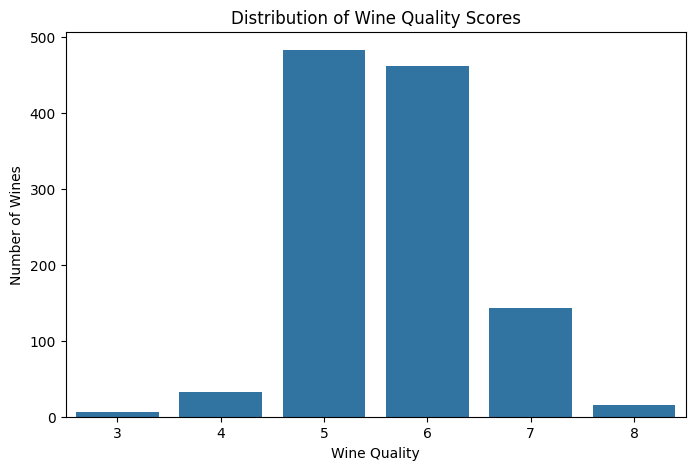

In [5]:
# Checking how many wines belong to each quality score

quality_counts = df["quality"].value_counts().sort_index()

print("Wine quality distribution:")
print(quality_counts)

# Showing the distribution with a bar chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="quality")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")
plt.show()

In [6]:
# Checking basic statistics of the wine features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


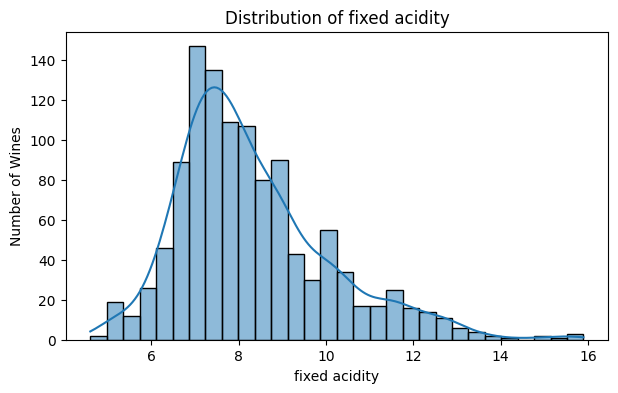

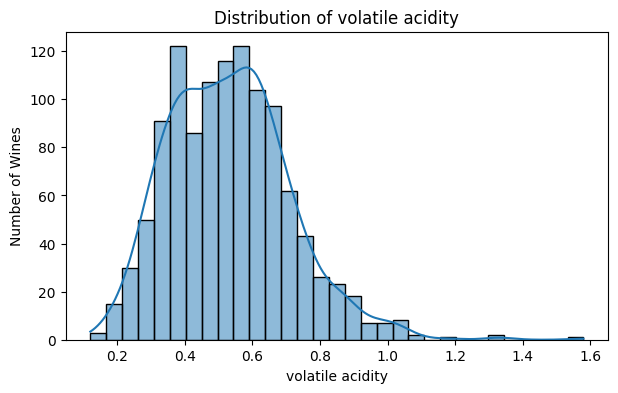

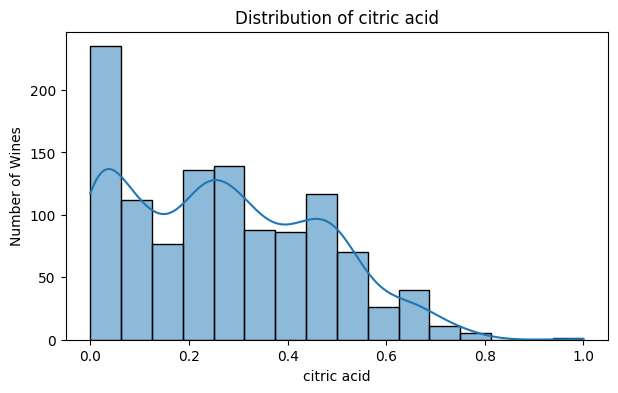

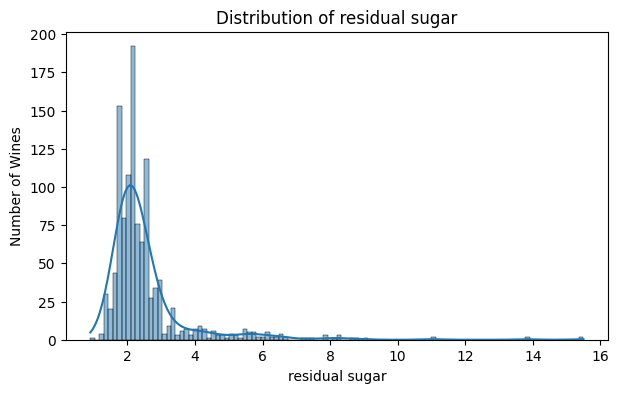

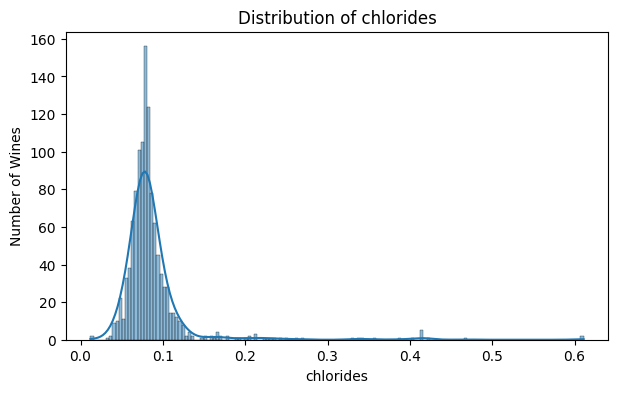

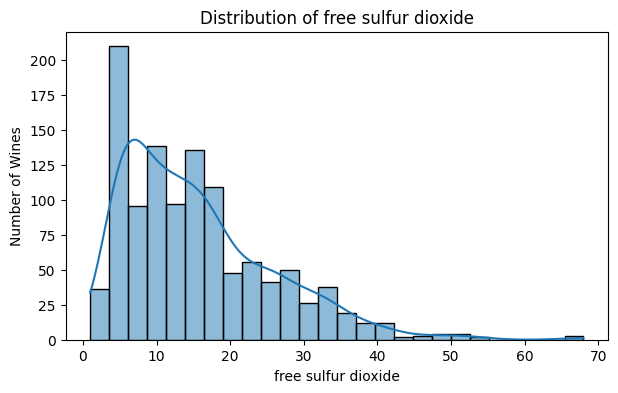

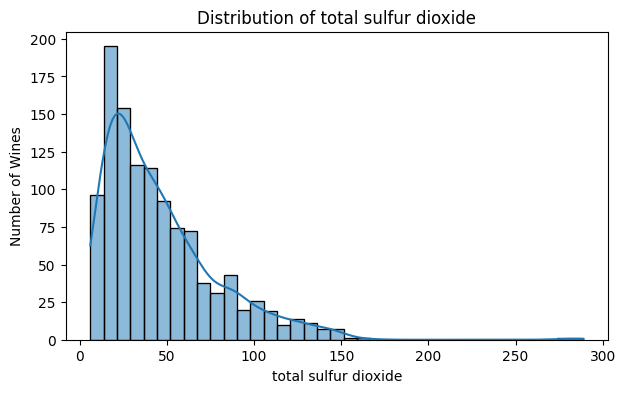

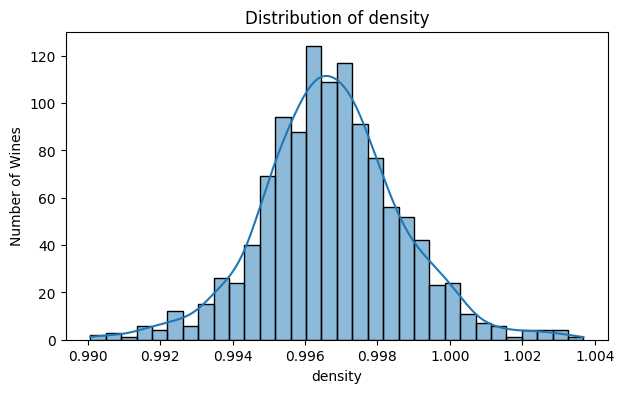

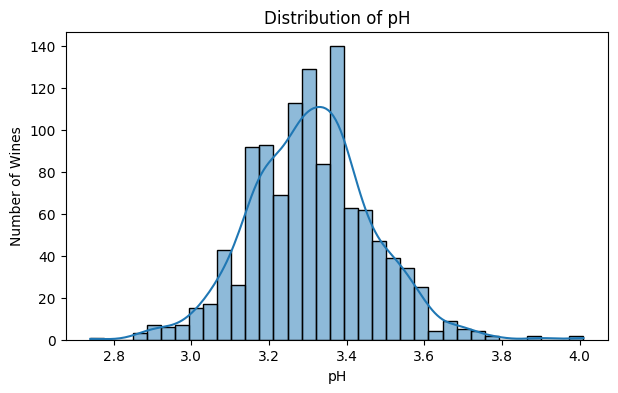

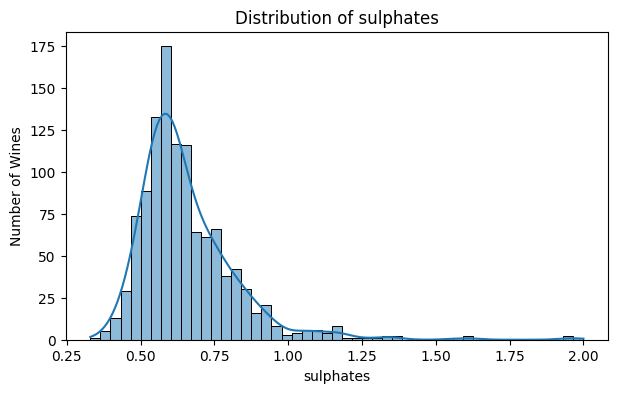

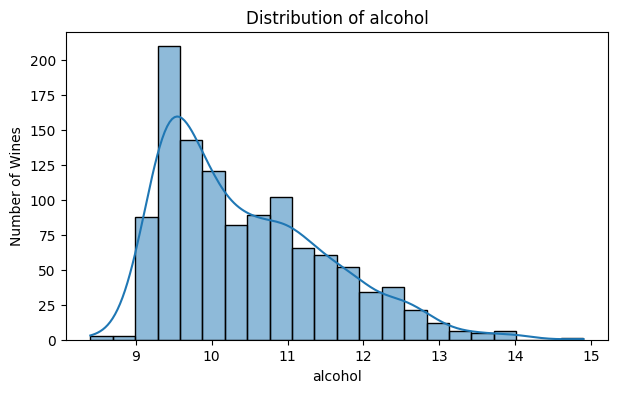

In [7]:
# Plotting the distribution of the main wine chemical features

features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

for feature in features:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[feature], kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Wines")
    plt.show()

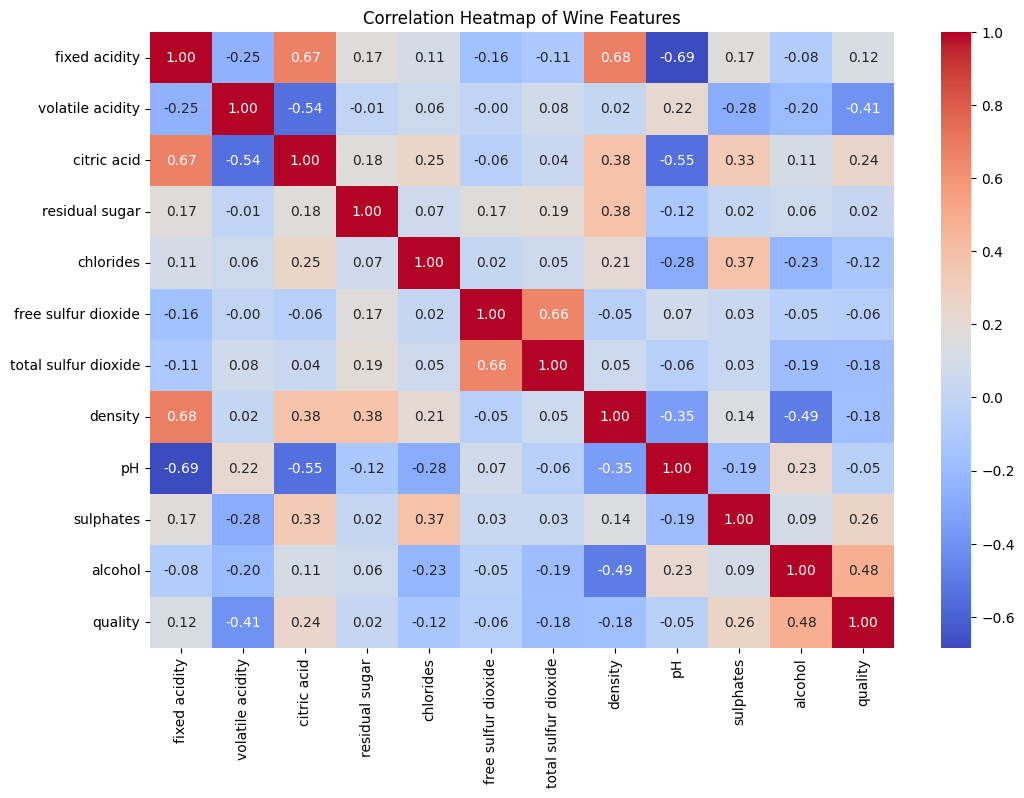

In [8]:
# Checking the correlation between the wine features

plt.figure(figsize=(12, 8))

correlation = df[features + ["quality"]].corr()

sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap of Wine Features")
plt.show()

In [9]:
# Checking the percentage of each wine quality class

quality_distribution = df["quality"].value_counts().sort_index()
quality_percentage = (quality_distribution / len(df) * 100).round(2)

class_summary = pd.DataFrame({
    "Number of Wines": quality_distribution,
    "Percentage": quality_percentage
})

class_summary

,Number of Wines,Percentage
quality,,
3,6,0.52
4,33,2.89
5,483,42.26
6,462,40.42
7,143,12.51
8,16,1.40


In [10]:
# Grouping the wine quality scores into three classes

def quality_group(quality):
    if quality <= 4:
        return "Low"
    elif quality <= 6:
        return "Medium"
    else:
        return "High"

df["quality_class"] = df["quality"].apply(quality_group)

print("Quality class distribution:")
print(df["quality_class"].value_counts())

print("\nQuality class percentages:")
print((df["quality_class"].value_counts(normalize=True) * 100).round(2))

Quality class distribution:
quality_class
Medium    945
High      159
Low        39
Name: count, dtype: int64

Quality class percentages:
quality_class
Medium    82.68
High      13.91
Low        3.41
Name: proportion, dtype: float64


In [11]:
# Selecting the wine features for the machine learning models

feature_columns = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

X = df[feature_columns]
y = df["quality_class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1143, 11)
Target shape: (1143,)


In [12]:
# Splitting the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data: (914, 11)
Testing data: (229, 11)

Training class distribution:
quality_class
Medium    756
High      127
Low        31
Name: count, dtype: int64

Testing class distribution:
quality_class
Medium    189
High       32
Low         8
Name: count, dtype: int64


In [13]:
# Scaling the features before training the models

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed!
Training data shape: (914, 11)
Testing data shape: (229, 11)


In [14]:
# Training the Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [15]:
# Evaluating the Random Forest model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

print("Confusion Matrix:")
rf_cm = confusion_matrix(y_test, rf_predictions)
print(rf_cm)

Random Forest Accuracy: 0.8603

Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.56      0.61        32
         Low       0.00      0.00      0.00         8
      Medium       0.89      0.95      0.92       189

    accuracy                           0.86       229
   macro avg       0.52      0.50      0.51       229
weighted avg       0.83      0.86      0.84       229

Confusion Matrix:
[[ 18   0  14]
 [  0   0   8]
 [  9   1 179]]


In [16]:
# Training the SGD classifier

from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

sgd_predictions = sgd_model.predict(X_test_scaled)

print("SGD model trained successfully!")

SGD model trained successfully!


In [17]:
# Evaluating the SGD model

sgd_accuracy = accuracy_score(y_test, sgd_predictions)

print("SGD Accuracy:", round(sgd_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, sgd_predictions))

print("Confusion Matrix:")
sgd_cm = confusion_matrix(y_test, sgd_predictions)
print(sgd_cm)

SGD Accuracy: 0.821

Classification Report:
              precision    recall  f1-score   support

        High       0.48      0.44      0.46        32
         Low       0.00      0.00      0.00         8
      Medium       0.87      0.92      0.89       189

    accuracy                           0.82       229
   macro avg       0.45      0.45      0.45       229
weighted avg       0.79      0.82      0.80       229

Confusion Matrix:
[[ 14   0  18]
 [  0   0   8]
 [ 15   0 174]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
# Training the SVC classifier

from sklearn.svm import SVC

svc_model = SVC(random_state=42)

svc_model.fit(X_train_scaled, y_train)

svc_predictions = svc_model.predict(X_test_scaled)

print("SVC model trained successfully!")

SVC model trained successfully!


In [19]:
# Checking how well the SVC model performed

svc_accuracy = accuracy_score(y_test, svc_predictions)

print("SVC Accuracy:", round(svc_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, svc_predictions))

print("Confusion Matrix:")
svc_cm = confusion_matrix(y_test, svc_predictions)
print(svc_cm)

SVC Accuracy: 0.8428

Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.25      0.36        32
         Low       0.00      0.00      0.00         8
      Medium       0.85      0.98      0.91       189

    accuracy                           0.84       229
   macro avg       0.51      0.41      0.42       229
weighted avg       0.80      0.84      0.80       229

Confusion Matrix:
[[  8   0  24]
 [  0   0   8]
 [  4   0 185]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                 Feature  Importance
10               alcohol    0.155432
1       volatile acidity    0.121587
9              sulphates    0.104312
2            citric acid    0.092809
7                density    0.088104
4              chlorides    0.087150
0          fixed acidity    0.080798
6   total sulfur dioxide    0.073440
3         residual sugar    0.073439
8                     pH    0.065370
5    free sulfur dioxide    0.057560


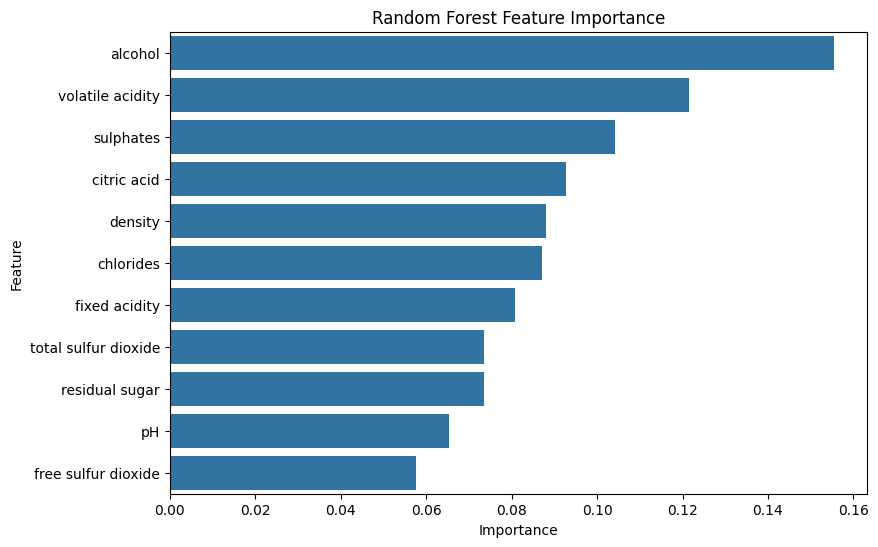

In [20]:
# Checking which features were important for the Random Forest model

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [21]:
# Comparing the three models

model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

model_comparison["Accuracy"] = model_comparison["Accuracy"].round(4)

model_comparison

,Model,Accuracy
0,Random Forest,0.8603
1,SGD,0.8210
2,SVC,0.8428


## Conclusion

In this project, I used the Wine Quality dataset to predict wine quality classes based on their physicochemical properties.

The original quality scores were grouped into three classes: Low (3-4), Medium (5-6), and High (7-8). The dataset had an imbalance between these classes, with Medium quality wines making up most of the data.

Three classification models were trained and compared:

- Random Forest Accuracy: 86.03%
- SGD Accuracy: 82.10%
- SVC Accuracy: 84.28%

Random Forest gave the highest accuracy among the three models. The feature importance analysis showed that alcohol, volatile acidity, and sulphates were among the more important features for the Random Forest model.

The results also showed that the models performed much better on the Medium class than the Low class. This is mainly related to the unequal number of samples in the quality classes.

Overall, this project helped me understand data exploration, class imbalance, feature engineering, classification models, model evaluation, and feature importance.